## Extended Data Fig. 10a & 10b

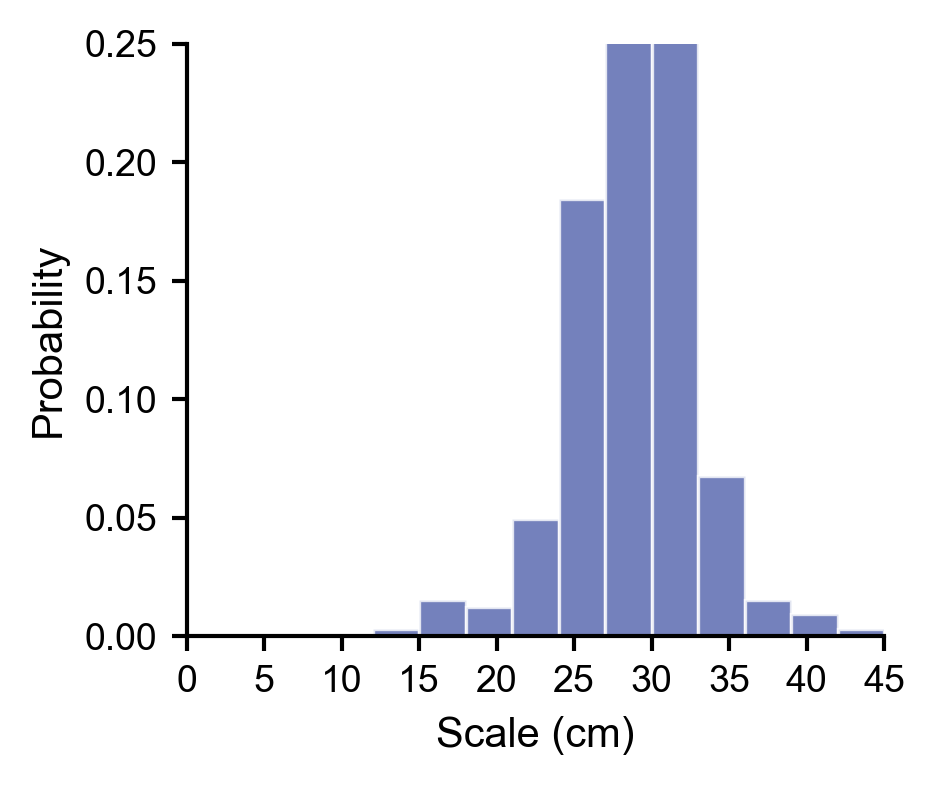

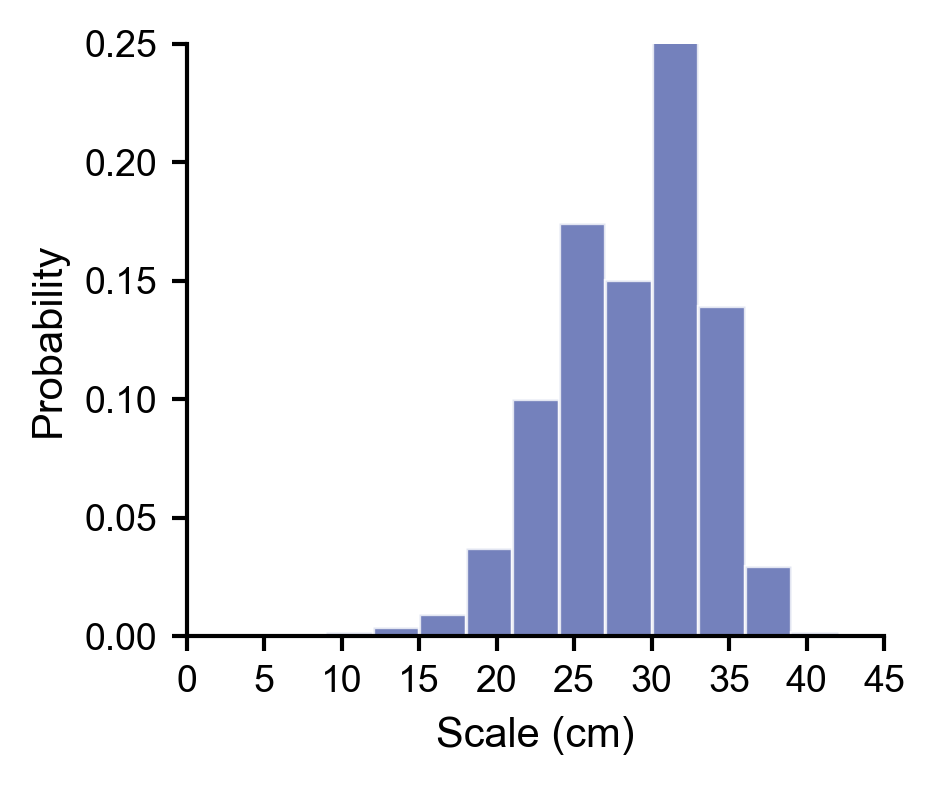

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Results4Plots/GCs_scale.csv")

for col in ["Stage", "Environment"]:
    df[col] = df[col].astype("string").str.strip().str.strip("'\"")

df["Scale_cm"] = pd.to_numeric(df["Scale_cm"], errors="coerce")

df = df[
    (df["Environment"] == "R")
    & (df["Stage"].isin(["early", "late"]))
    & (df["Scale_cm"].notna())
].copy()

x_max = int(np.ceil(df["Scale_cm"].max() / 5) * 5)
edges = np.arange(0, x_max + 3, 3)
xticks = np.arange(0, x_max + 1, 5)

colorR = np.array([81, 98, 172]) / 255.0

def plot_scale_distribution(stage):
    vals = df.loc[df["Stage"] == stage, "Scale_cm"].to_numpy(dtype=float)

    if vals.size == 0:
        return

    weights = np.ones(vals.size) / vals.size

    fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)

    ax.hist(
        vals,
        bins=edges,
        weights=weights,
        color=colorR,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.tick_params(axis="both", direction="out", length=3.5, width=1, labelsize=9)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname("Arial")

    ax.set_xlabel("Scale (cm)", fontsize=10, fontname="Arial")
    ax.set_ylabel("Probability", fontsize=10, fontname="Arial")

    ax.set_xlim(0, x_max)
    ax.set_xticks(xticks)
    ax.set_ylim(0, 0.25)
    ax.set_yticks(np.arange(0, 0.251, 0.05))

    plt.tight_layout(pad=0.3)
    plt.show()
    plt.close(fig)

plot_scale_distribution("early")
plot_scale_distribution("late")